In [1]:
from dotenv import load_dotenv
load_dotenv()  # load API keys

from typing import Literal
from pydantic import BaseModel
from langchain_core.prompts import ChatPromptTemplate
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_google_genai import ChatGoogleGenerativeAI,GoogleGenerativeAIEmbeddings
from langchain_chroma import Chroma
from langchain_core.documents import Document
from langgraph.graph import StateGraph, START, END, MessagesState

C:\Users\gandh\AppData\Local\Temp\ipykernel_3400\1653374106.py:7: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader


In [2]:
# Section 2 — Document Loading
loader = PyPDFLoader("../documents/evs_oil_price_shock.pdf")
raw_docs = loader.load()

print(f"Loaded {len(raw_docs)} pages")

Loaded 15 pages


In [3]:
# Section 3 — Text Chunking
splitter = RecursiveCharacterTextSplitter(chunk_size=900, chunk_overlap=150)
chunks = splitter.split_documents(raw_docs)

print(f"Split into {len(chunks)} chunks")

Split into 51 chunks


In [4]:
chunks = chunks[:10]

In [5]:
len(chunks)

10

In [9]:
# section 4
embeddings = GoogleGenerativeAIEmbeddings(model='gemini-embedding-001')

In [ ]:
# in-memory only; re-running this cell re-embeds from scratch
vectorstore = Chroma(
    collection_name="rag_conditional",
    embedding_function=embeddings,
)

vectorstore.add_documents(documents=chunks)

retriever = vectorstore.as_retriever(search_kwargs={"k": 1})
print("Vector store ready")

Vector store ready


In [11]:
# Section 6 — LLM
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash-lite")

In [12]:
# Section 7 — State Definition
class AgenticRAGState(MessagesState):
    
    query: str
    retrieved_docs: list[Document] | None
    context: str
    generation: str
    needs_retrieval: bool

In [13]:
# structured output 
class RouteDecision(BaseModel):
    needs_retrieval: bool

In [14]:
def route_question(state: AgenticRAGState) -> dict:

    prompt_template = ChatPromptTemplate.from_messages([
        ("system", "Classify whether the following question requires retrieving information from a specialized document, or can be answered from your own general knowledge."),
        ("human", "{query}"),
    ])

    chain = prompt_template | llm.with_structured_output(RouteDecision)

    decision = chain.invoke({"query": state["query"]})

    return {"needs_retrieval": decision.needs_retrieval}

In [15]:
# retrieve node — fetches relevant documents from the vector store
def retrieve(state: AgenticRAGState) -> dict:
    
    docs = retriever.invoke(state["query"])
    
    if docs:
        context = "\n\n".join(doc.page_content for doc in docs)

    return {"retrieved_docs": docs, "context": context}

In [16]:
# generate node — produces the final answer, with or without retrieved context
def generate(state: AgenticRAGState) -> dict:
    
    query = state["query"]
    context = state.get("context") or ""


    if context:    
        prompt_template = ChatPromptTemplate.from_messages([
            ("system", "Answer the question using only the context below.\n\nContext:\n{context}"),
            ("human", "{query}"),
        ])
        
        response = (prompt_template | llm).invoke({"context": context, "query": query})
    
    else:
        prompt_template = ChatPromptTemplate.from_messages([
            ("system", "Answer the following question from your general knowledge."),
            ("human", "{query}"),
        ])
        
        response = (prompt_template | llm).invoke({"query": query})

    return {"generation": response.content}

In [17]:
def route_after_classification(state: AgenticRAGState) -> Literal['retrieve','generate']:
    if state['needs_retrieval']:
        return 'retrieve'
    else:
        return 'generate'


In [19]:
graph = StateGraph(AgenticRAGState)

graph.add_node('route_question',route_question)
graph.add_node('retrieve',retrieve)
graph.add_node('generate',generate)

graph.add_edge(START, 'route_question')
graph.add_conditional_edges('route_question',route_after_classification)
graph.add_edge('retrieve', 'generate')
graph.add_edge('generate', END)

app = graph.compile()

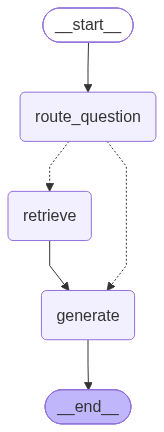

In [20]:
app

In [22]:
general_query = "What is the capital of India?"

result_general = app.invoke({"query": general_query, "messages": []})

In [23]:
result_general

{'messages': [],
 'query': 'What is the capital of India?',
 'generation': 'The capital of India is **New Delhi**.',
 'needs_retrieval': False}